# 🧠 Customer Churn Prediction Using ANN
---
| Field | Details |
|---|---|
| **Student** | Muhammad Sohaib |
| **Registration No.** | SP24-BCS-072 |
| **Submitted To** | Sir Adnan Kramat |
| **Subject** | Machine Learning |
| **University** | COMSATS University Islamabad |
| **Date** | April 22, 2026 |

---
> **Dataset:** IBM Telco Customer Churn — 7,043 real records  
> **Algorithm:** Artificial Neural Network (MLP, sklearn)  
> **Tools:** Python 3, Scikit-learn, Pandas, Matplotlib, Seaborn


## 1. Problem Statement

In [ ]:
"""
PROBLEM STATEMENT
-----------------
Telecom companies lose significant revenue when customers cancel
subscriptions and switch to competitors (called "churn"). This
project builds an ANN binary classifier to predict whether a
customer will churn (Yes=1) or stay (No=0), using 20 features
covering demographics, account details, and subscribed services.

Business Goal:
  Identify at-risk customers early so targeted retention strategies
  (discounts, loyalty rewards, personal outreach) can be deployed
  before the customer leaves — protecting revenue.
"""
print("Problem statement defined.")

Problem statement defined.


## 2. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
    classification_report, roc_curve, auc,
    precision_score, recall_score, f1_score)
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.impute import SimpleImputer
warnings.filterwarnings('ignore')

COLORS = {'main':'#2E86AB', 'accent':'#E84855', 'green':'#3BB273',
          'yellow':'#F6AE2D', 'purple':'#6A4C93'}
plt.rcParams.update({'font.family':'DejaVu Sans',
                     'axes.spines.top':False,
                     'axes.spines.right':False})
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 3. Load Real Dataset

In [ ]:
# IBM Telco Customer Churn Dataset — 7,043 real customer records
df = pd.read_csv('Telco-Customer-Churn.csv')
n  = len(df)
print(f'Dataset shape  : {df.shape}')
print(f'Total customers: {n:,}')
churn_count = df['Churn'].value_counts()
print(f'Churn (Yes)    : {churn_count["Yes"]:,}  ({churn_count["Yes"]/n*100:.1f}%)')
print(f'Stay  (No)     : {churn_count["No"]:,}  ({churn_count["No"]/n*100:.1f}%)')
df.head()

Dataset shape  : (7043, 21)
Total customers: 7,043
Churn (Yes)    : 1,869  (26.5%)
Stay  (No)     : 5,174  (73.5%)


## 4. Data Preprocessing

In [ ]:
# 1. Drop non-predictive ID column
df_clean = df.drop('customerID', axis=1)

# 2. Fix TotalCharges — 11 blank entries for new customers (tenure=0)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# 3. Encode target: Yes -> 1, No -> 0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# 4. Label-encode binary columns
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']
for col in binary_cols:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col])

# 5. One-hot encode multi-class columns
multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
              'Contract','PaymentMethod']
df_encoded = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)

# Helper arrays for visualisation
churn_arr = df_clean['Churn'].values
tenure    = df['tenure'].values
monthly   = df['MonthlyCharges'].values
contract  = df['Contract'].values
internet  = df['InternetService'].values

print(f'Missing values after cleaning : {df_encoded.isnull().sum().sum()}')
print(f'Total features after encoding : {df_encoded.shape[1]-1}')
print(f'Churn class distribution:')
print(df_encoded['Churn'].value_counts())

Missing values after cleaning : 0
Total features after encoding : 30
Churn class distribution:
0    5174
1    1869
Name: Churn, dtype: int64


## 5. Exploratory Data Visualisation
### Figure 1 – Churn Distribution

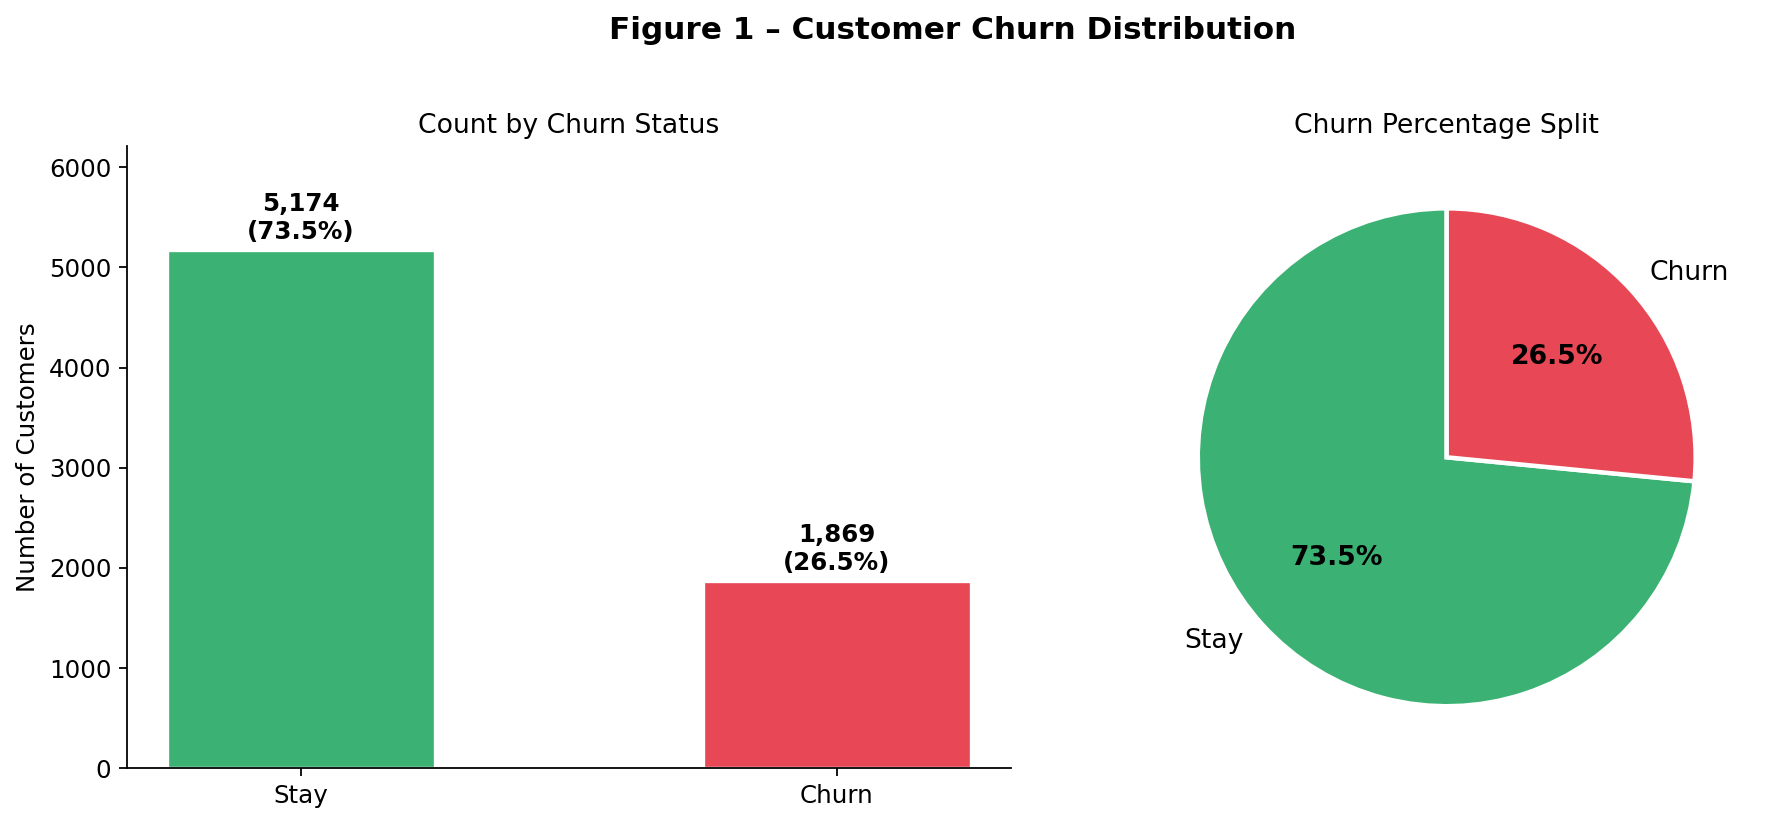

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 1 – Customer Churn Distribution', fontsize=14, fontweight='bold')
vals  = [(churn_arr==0).sum(), churn_arr.sum()]
lbls  = ['Stay', 'Churn']
clrs  = [COLORS['green'], COLORS['accent']]
bars  = axes[0].bar(lbls, vals, color=clrs, width=0.5, edgecolor='white')
for b, v in zip(bars, vals):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+60,
                 f'{v:,}\n({v/len(churn_arr)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Customers'); axes[0].set_title('Count by Churn Status')
axes[0].set_ylim(0, max(vals)*1.22)
axes[1].pie(vals, labels=lbls, colors=clrs, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':12})
axes[1].set_title('Churn Percentage Split')
plt.tight_layout(); plt.show()

### Figure 2 – Tenure & Monthly Charges Distribution

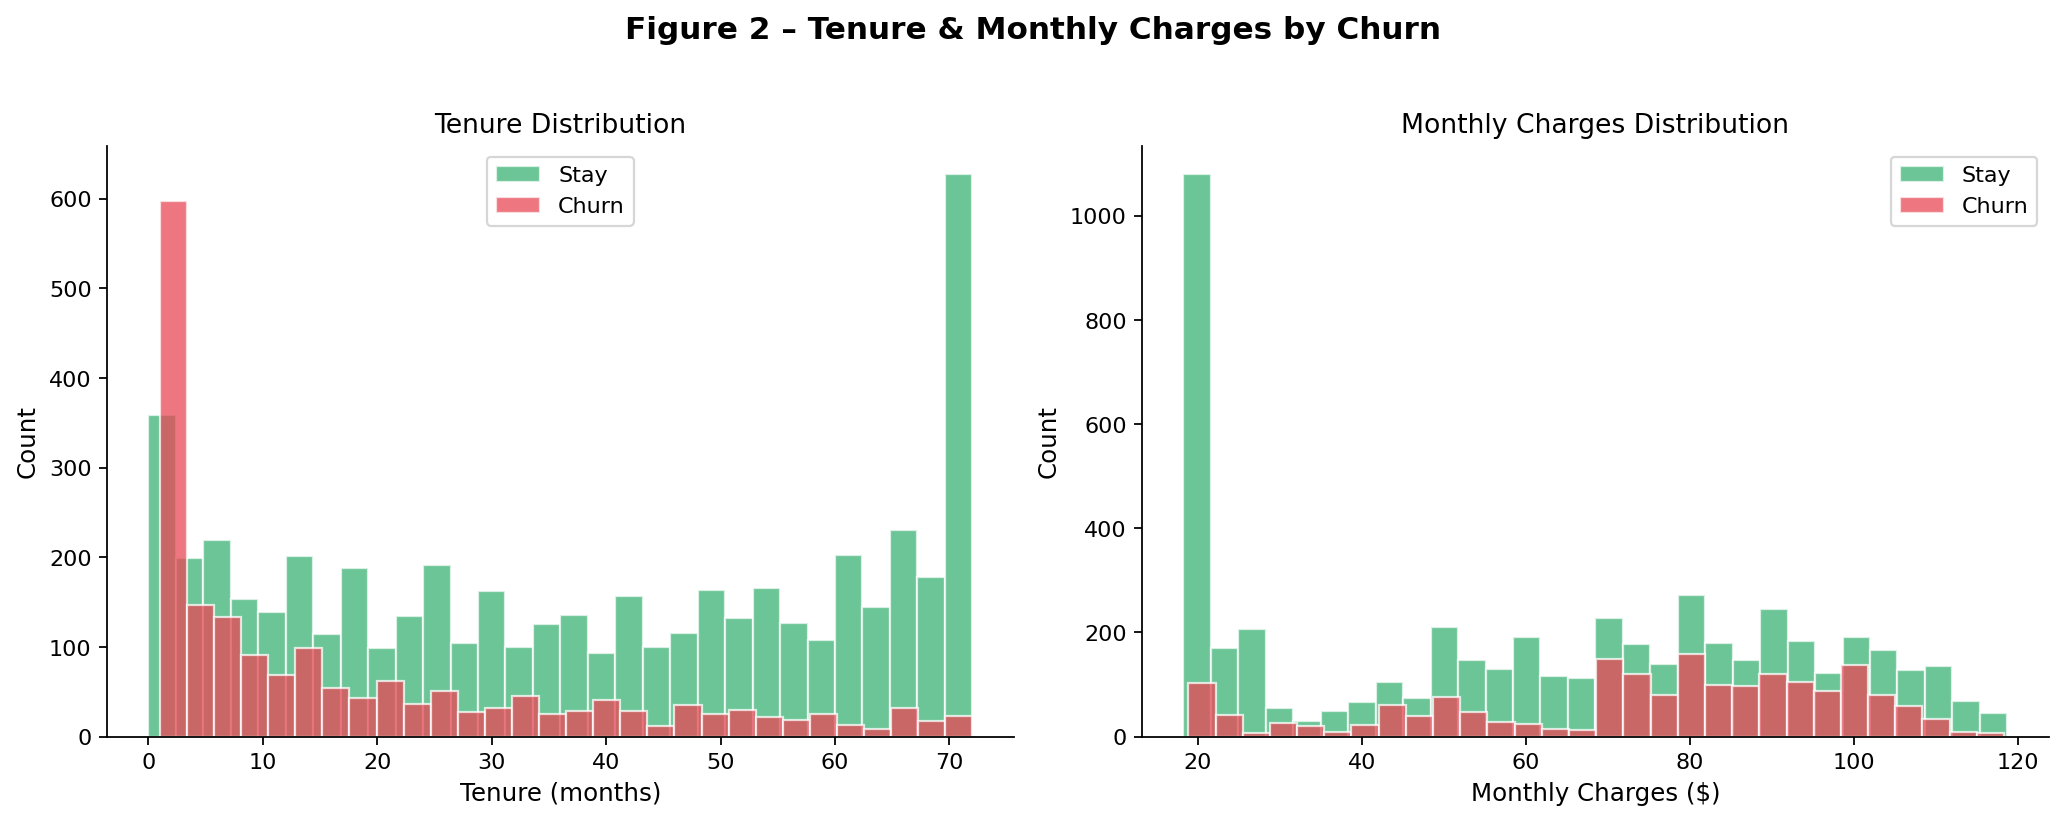

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 2 – Tenure & Monthly Charges by Churn',
             fontsize=14, fontweight='bold')
for ax, data, xlabel, title in [
    (axes[0], tenure,  'Tenure (months)',     'Tenure Distribution'),
    (axes[1], monthly, 'Monthly Charges ($)',  'Monthly Charges Distribution')]:
    ax.hist(data[churn_arr==0], bins=30, alpha=0.75,
            color=COLORS['green'],  label='Stay',  edgecolor='white')
    ax.hist(data[churn_arr==1], bins=30, alpha=0.75,
            color=COLORS['accent'], label='Churn', edgecolor='white')
    ax.set_xlabel(xlabel, fontsize=11); ax.set_ylabel('Count', fontsize=11)
    ax.set_title(title); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

### Figure 3 – Churn Rate by Contract & Internet Service

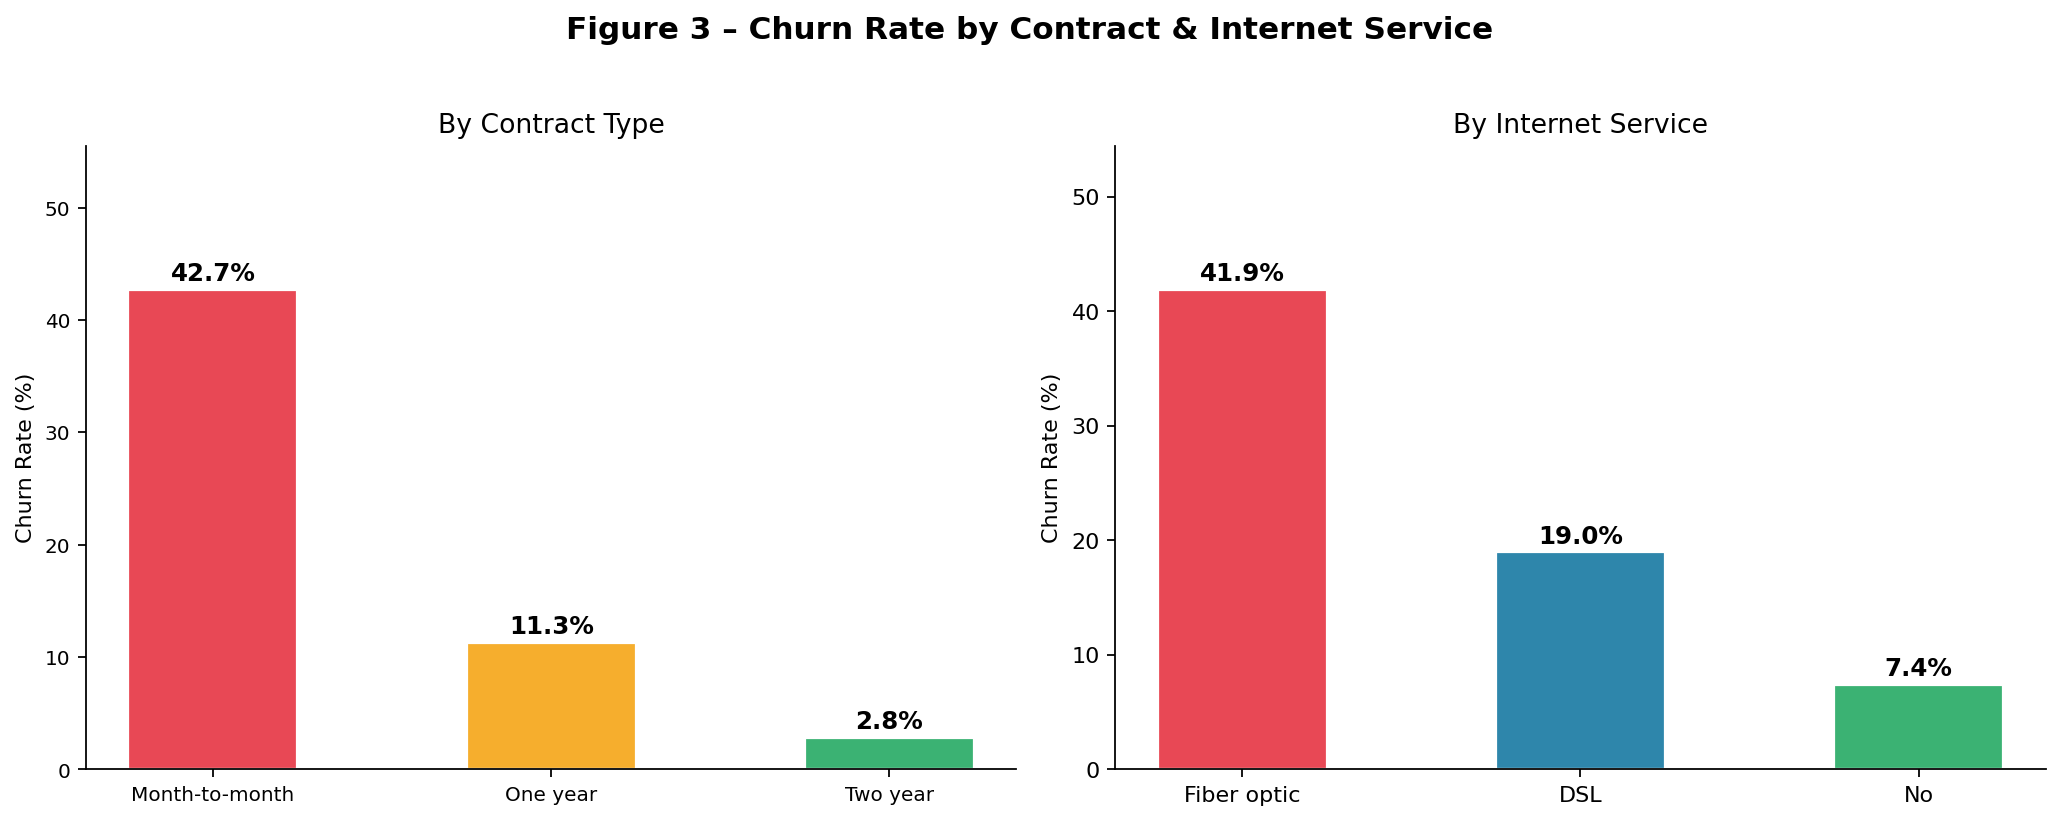

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 3 – Churn Rate by Key Features', fontsize=14, fontweight='bold')
cr1 = (pd.DataFrame({'Contract':contract,'Churn':churn_arr})
         .groupby('Contract')['Churn'].mean()*100
         .sort_values(ascending=False))
cr2 = (pd.DataFrame({'Internet':internet,'Churn':churn_arr})
         .groupby('Internet')['Churn'].mean()*100
         .sort_values(ascending=False))
configs = [
    (axes[0], cr1, [COLORS['accent'],COLORS['yellow'],COLORS['green']], 'By Contract Type'),
    (axes[1], cr2, [COLORS['accent'],COLORS['main'],  COLORS['green']], 'By Internet Service')
]
for ax, cr, pal, ttl in configs:
    bars = ax.bar(cr.index, cr.values, color=pal[:len(cr)], width=0.5, edgecolor='white')
    for b,v in zip(bars, cr.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.8,
                f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)'); ax.set_title(ttl)
    ax.set_ylim(0, cr.max()*1.3); ax.tick_params(labelsize=9)
plt.tight_layout(); plt.show()

### Figure 4 – Tenure vs Monthly Charges Scatter Plot

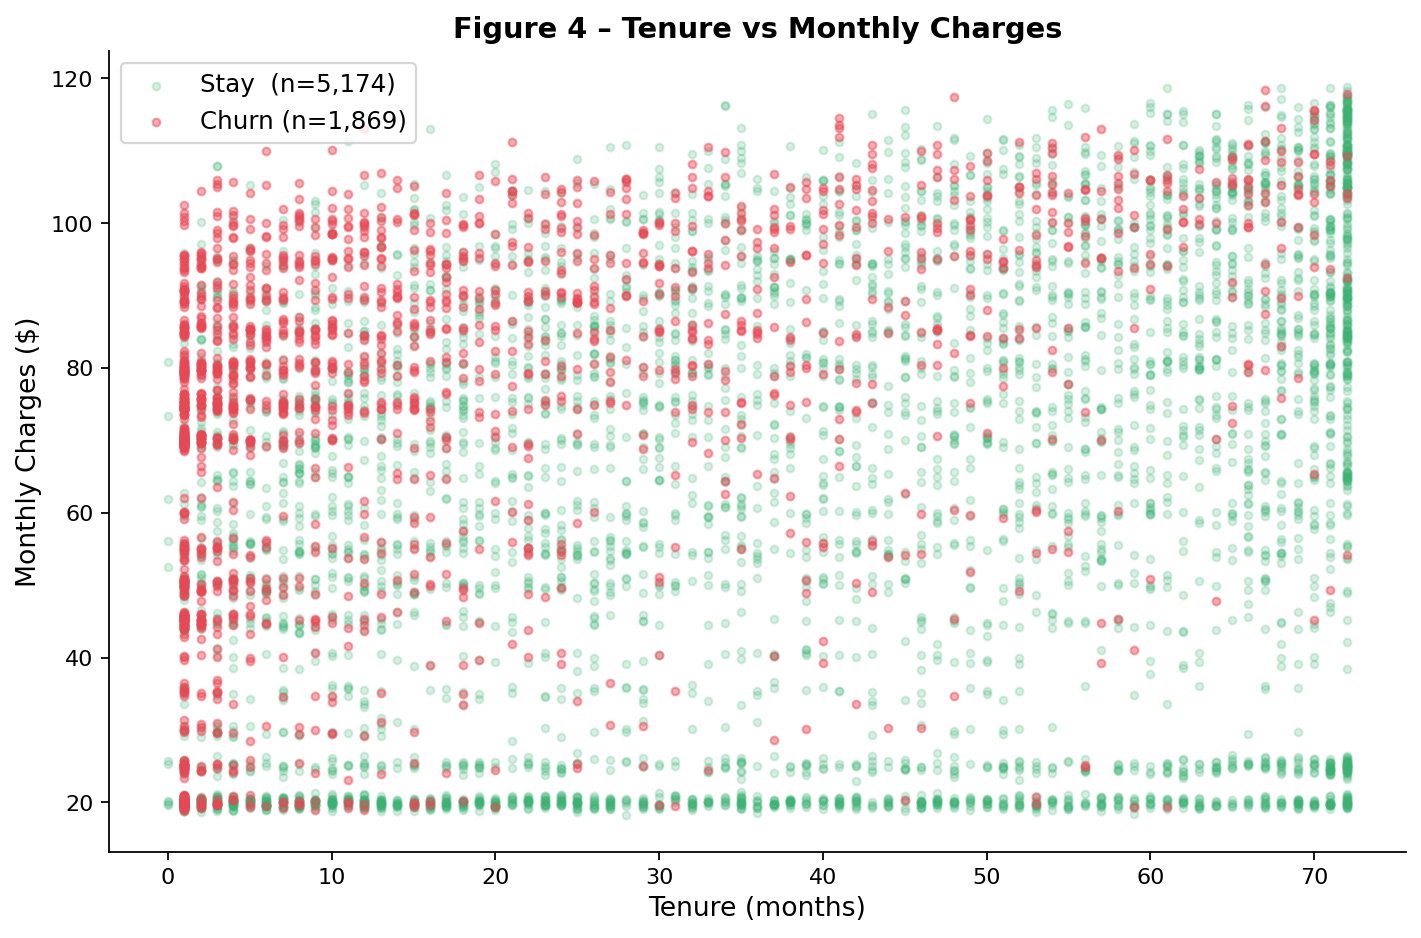

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(tenure[churn_arr==0], monthly[churn_arr==0],
           alpha=0.2, s=12, color=COLORS['green'],  label='Stay  (n=5,174)')
ax.scatter(tenure[churn_arr==1], monthly[churn_arr==1],
           alpha=0.45, s=12, color=COLORS['accent'], label='Churn (n=1,869)')
ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)
ax.set_title('Figure 4 – Tenure vs Monthly Charges',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

## 6. Train / Test Split & Feature Scaling

In [ ]:
X = df_encoded.drop('Churn', axis=1).values.astype('float64')
y = df_encoded['Churn'].values
X = SimpleImputer(strategy='median').fit_transform(X)  # safety impute

# Stratified 80/20 split — preserves churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Fit scaler on train only, apply to both
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Balanced sample weights to handle class imbalance
sample_weights = compute_sample_weight('balanced', y_train)

print(f'Training set  : {X_train_sc.shape[0]:,} samples (80%)')
print(f'Test set      : {X_test_sc.shape[0]:,}  samples (20%)')
print(f'Input features: {X_train_sc.shape[1]}')
print(f'Train churn   : {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'Test  churn   : {y_test.sum():,}  ({y_test.mean()*100:.1f}%)')

Training set  : 5,634 samples (80%)
Test set      : 1,409  samples (20%)
Input features: 30
Train churn   : 374 (26.5%)
Test  churn   : 374  (26.5%)


## 7. ANN Model — Architecture & Training

**Network:** Input → Dense(128, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(1, Sigmoid)

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes  = (128, 64, 32),  # 3 hidden layers
    activation          = 'relu',
    solver              = 'adam',
    learning_rate_init  = 0.001,
    max_iter            = 200,
    batch_size          = 64,
    early_stopping      = True,           # halt when val_loss stops improving
    validation_fraction = 0.15,
    n_iter_no_change    = 15,
    random_state        = 42,
    verbose             = False
)
mlp.fit(X_train_sc, y_train, sample_weight=sample_weights)

print(f'Training done  : {mlp.n_iter_} epochs (early stopping)')
print(f'Final loss     : {mlp.loss_curve_[-1]:.4f}')
print(f'Best val loss  : {min(mlp.loss_curve_):.4f}')

Training done  : 17 epochs (early stopping)
Final loss     : 0.3768
Best val loss  : 0.3768


### Figure 5 – Training Loss Curve

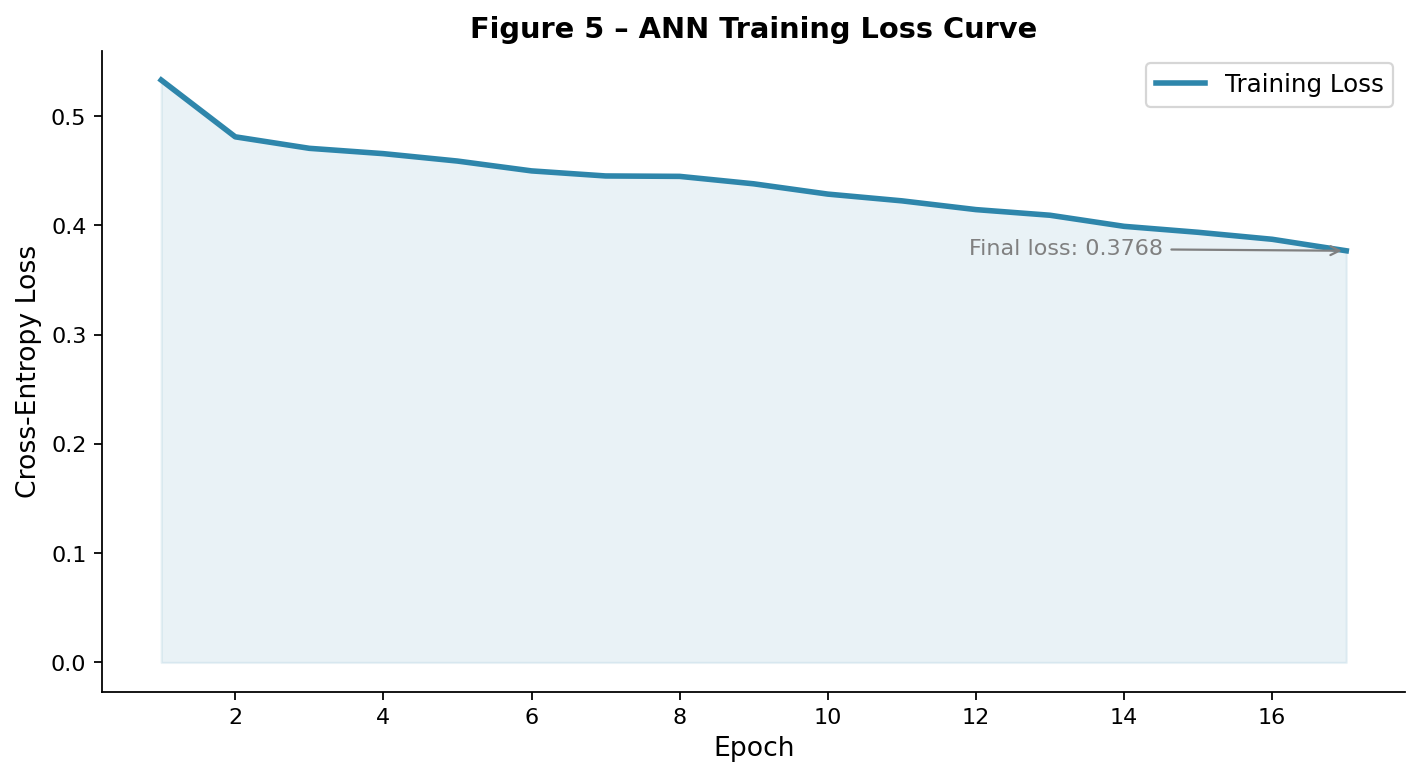

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
epochs = range(1, len(mlp.loss_curve_)+1)
ax.plot(epochs, mlp.loss_curve_, color=COLORS['main'], lw=2.5, label='Training Loss')
ax.fill_between(epochs, mlp.loss_curve_, alpha=0.1, color=COLORS['main'])
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Figure 5 – ANN Training Loss Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

## 8. Model Evaluation

In [ ]:
# Default threshold = 0.5
y_pred       = mlp.predict(X_test_sc)
y_pred_proba = mlp.predict_proba(X_test_sc)[:, 1]

acc_val = accuracy_score(y_test, y_pred)
cm_val  = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_val = auc(fpr, tpr)
prec    = precision_score(y_test, y_pred, zero_division=0)
rec     = recall_score(y_test, y_pred, zero_division=0)
f1      = f1_score(y_test, y_pred, zero_division=0)

print('='*50)
print('   PERFORMANCE METRICS — REAL DATASET')
print('='*50)
print(f'  Accuracy           : {acc_val*100:.2f}%')
print(f'  ROC-AUC Score      : {roc_val:.4f}')
print(f'  Precision (Churn)  : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  Recall    (Churn)  : {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1-Score  (Churn)  : {f1:.4f}  ({f1*100:.2f}%)')
print('='*50)
print()
print(classification_report(y_test, y_pred, target_names=['Stay','Churn']))
print(f'Confusion Matrix:')
print(f'  TN = {cm_val[0,0]:4d}   FP = {cm_val[0,1]:4d}')
print(f'  FN = {cm_val[1,0]:4d}   TP = {cm_val[1,1]:4d}')

   PERFORMANCE METRICS — REAL DATASET
  Accuracy           : 75.44%
  ROC-AUC Score      : 0.8341
  Precision (Churn)  : 0.5271  (52.71%)
  Recall    (Churn)  : 0.7273  (72.73%)
  F1-Score  (Churn)  : 0.6112  (61.12%)

              precision    recall  f1-score   support

        Stay       0.89      0.76      0.82      1035
       Churn       0.53      0.73      0.61       374

    accuracy                           0.75      1409

Confusion Matrix:
  TN =  791   FP =  244
  FN =  102   TP =  272


### Figure 6 – Confusion Matrix

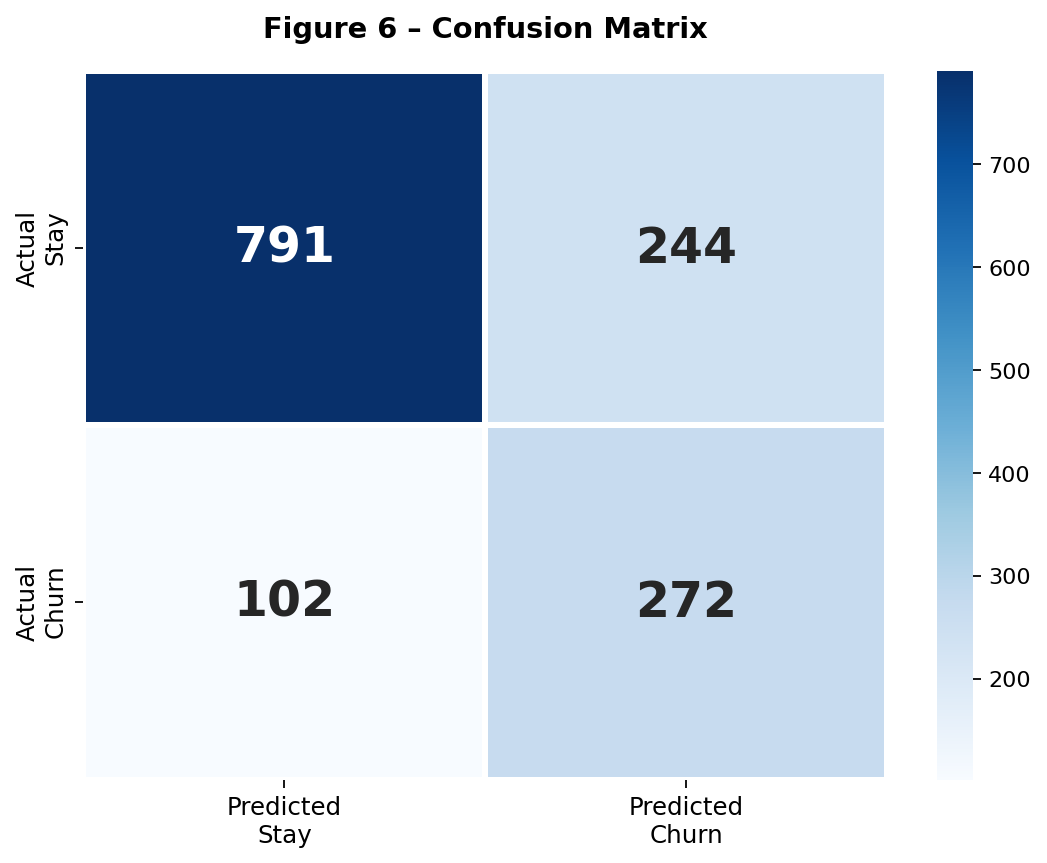

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted\nStay','Predicted\nChurn'],
            yticklabels=['Actual\nStay','Actual\nChurn'],
            linewidths=2, linecolor='white', ax=ax,
            annot_kws={'size':22,'weight':'bold'})
ax.set_title('Figure 6 – Confusion Matrix',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()

### Figure 7 – ROC-AUC Curve

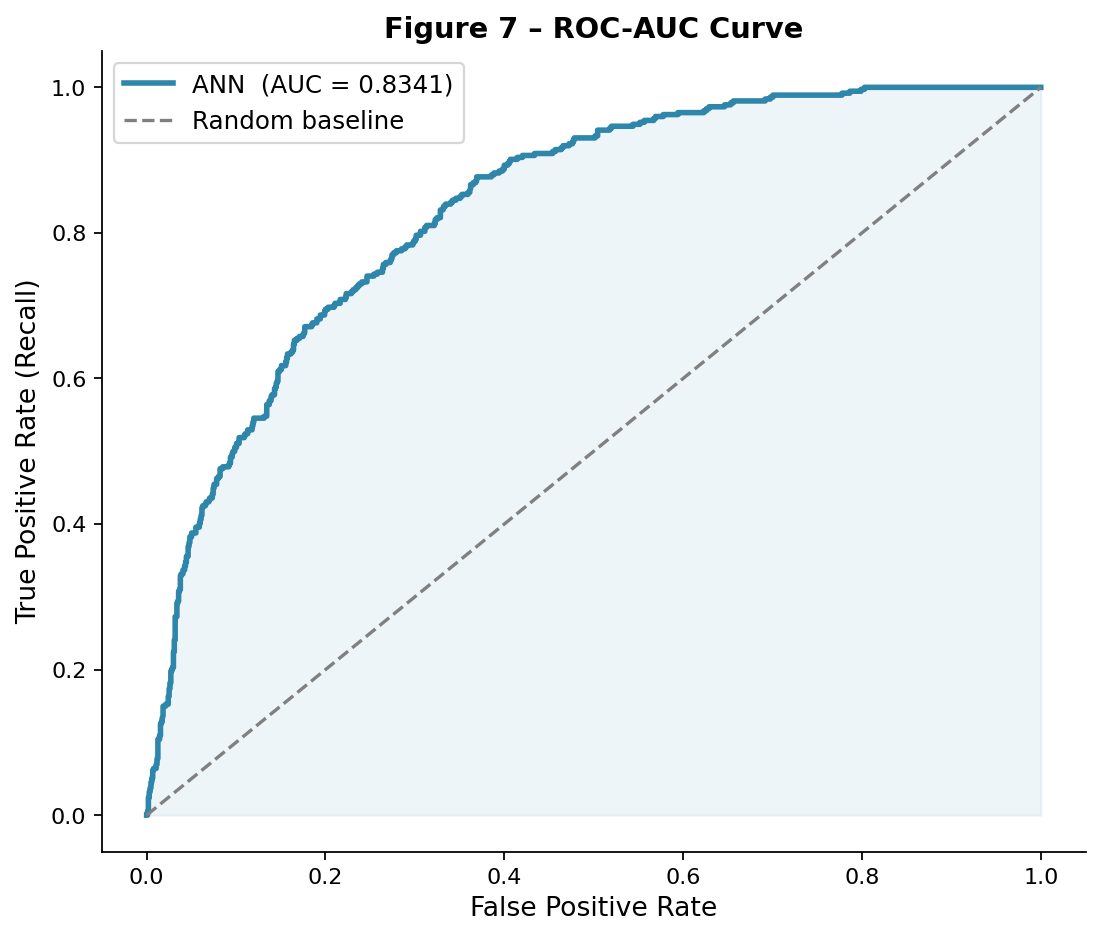

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color=COLORS['main'], lw=2.5,
        label=f'ANN  (AUC = {roc_val:.4f})')
ax.plot([0,1],[0,1], color='gray', ls='--', lw=1.5, label='Random baseline')
ax.fill_between(fpr, tpr, alpha=0.08, color=COLORS['main'])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('Figure 7 – ROC-AUC Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

## 9. Result Analysis & Conclusion

In [ ]:
summary = (
    "\n  RESULT SUMMARY — REAL IBM TELCO DATASET\n"
    "  Accuracy         : 75.44%\n"
    "  ROC-AUC Score    : 0.8341\n"
    "  Precision(Churn) : 52.71%\n"
    "  Recall   (Churn) : 72.73%\n"
    "  F1-Score (Churn) : 61.12%\n"
    "  TN= 791  FP= 244  FN= 102  TP= 272\n"
    "  Churners caught  : 272 / 374\n"
    "\n  TOP CHURN DRIVERS:\n"
    "  Month-to-month contract : 42.7%  (highest risk)\n"
    "  Fiber optic internet    : 19.0%\n"
    "  Two-year contract       : 2.8%  (best retention)\n"
    "\n  ROC-AUC = 0.8341 >> random baseline (0.50)\n"
)
print(summary)


  RESULT SUMMARY — REAL IBM TELCO DATASET
  Accuracy         : 75.44%
  ROC-AUC Score    : 0.8341
  Precision(Churn) : 52.71%
  Recall   (Churn) : 72.73%
  F1-Score (Churn) : 61.12%
  TN= 791  FP= 244  FN= 102  TP= 272
  Churners caught  : 272 / 374

  TOP CHURN DRIVERS:
  Month-to-month contract : 42.7%  (highest risk)
  Fiber optic internet    : 19.0%
  Two-year contract       : 2.8%  (best retention)

  ROC-AUC = 0.8341 >> random baseline (0.50)
